# 1D CNN over envelope

This notebook trains the envelope-only model. Inputs are `envelope_db` arrays from `dataset/samples/*.npz`.

In [4]:
from pathlib import Path
import sys

METHOD_DIR = Path.cwd()
if METHOD_DIR.name != "1d_cnn_envelope":
    METHOD_DIR = Path("methods/1d_cnn_envelope").resolve()
sys.path.insert(0, str(METHOD_DIR))

from train_envelope_1d_cnn import INDEX_TO_LABEL, LABEL_TO_INDEX, EnvelopeCNN, find_project_root, train

PROJECT_ROOT = find_project_root()
PROJECT_ROOT
DATASET_DIR = PROJECT_ROOT / "dataset_v2"

In [5]:
from train_envelope_1d_cnn import load_metadata, build_loaders, EnvelopeCNN, run_epoch, predict_loader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import torch
import numpy as np
import json

EPOCHS = 20
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
SEED = 42

metadata = load_metadata(PROJECT_ROOT)
metadata = metadata.copy()

# Важно: load_metadata по умолчанию читает dataset, поэтому читаем dataset_v2 вручную
import pandas as pd
metadata = pd.read_csv(DATASET_DIR / "metadata.csv")
metadata = metadata[metadata["label"].isin(LABEL_TO_INDEX)].copy()
metadata["target"] = metadata["label"].map(LABEL_TO_INDEX).astype(int)

loaders, frames = build_loaders(metadata, DATASET_DIR, BATCH_SIZE)

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EnvelopeCNN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()

best_state = None
best_val_f1 = -1.0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1, _, _ = run_epoch(model, loaders["train"], criterion, optimizer, device, train=True)
    val_loss, val_f1, _, _ = run_epoch(model, loaders["val"], criterion, optimizer, device, train=False)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_f1": val_f1,
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(f"epoch {epoch:02d}: train_loss={train_loss:.4f} train_f1={train_f1:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f}")

model.load_state_dict(best_state)

val_y, val_pred, _ = predict_loader(model, loaders["val"], device)
test_y, test_pred, test_prob = predict_loader(model, loaders["test"], device)

report = {
    "model_kind": "envelope_1d_dataset_v2",
    "dataset_dir": str(DATASET_DIR),
    "train_samples": int(len(frames["train"])),
    "val_samples": int(len(frames["val"])),
    "test_samples": int(len(frames["test"])),
    "best_val_f1": float(best_val_f1),
    "history": history,
}

predictions = frames["test"][["sample_id", "source_file", "segment_start", "segment_end", "label", "png_path", "npz_path"]].copy()
predictions["predicted"] = [INDEX_TO_LABEL[int(value)] for value in test_pred]
predictions["prob_no_burst"] = test_prob[:, 0]
predictions["prob_burst"] = test_prob[:, 1]

out_dir = METHOD_DIR / "reports"
model_dir = METHOD_DIR / "models"
out_dir.mkdir(exist_ok=True)
model_dir.mkdir(exist_ok=True)

torch.save(
    {"model_kind": "envelope_1d_dataset_v2", "model_state_dict": model.state_dict(), "label_to_index": LABEL_TO_INDEX},
    model_dir / "envelope_1d_dataset_v2.pt"
)
predictions.to_csv(out_dir / "envelope_1d_dataset_v2_predictions.csv", index=False)
(out_dir / "envelope_1d_dataset_v2_metrics.json").write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")

print("VAL")
print(confusion_matrix(val_y, val_pred))
print(classification_report(val_y, val_pred, target_names=["no_burst", "burst"], zero_division=0))

print("TEST")
print(confusion_matrix(test_y, test_pred))
print(classification_report(test_y, test_pred, target_names=["no_burst", "burst"], zero_division=0))


epoch 01: train_loss=0.4221 train_f1=0.7795 val_loss=0.3314 val_f1=0.8789
epoch 02: train_loss=0.3122 train_f1=0.8433 val_loss=0.2562 val_f1=0.8867
epoch 03: train_loss=0.2841 train_f1=0.8569 val_loss=0.2552 val_f1=0.8490
epoch 04: train_loss=0.2758 train_f1=0.8605 val_loss=0.2493 val_f1=0.8559
epoch 05: train_loss=0.2735 train_f1=0.8721 val_loss=0.2240 val_f1=0.9022
epoch 06: train_loss=0.2655 train_f1=0.8747 val_loss=0.2385 val_f1=0.8670
epoch 07: train_loss=0.2535 train_f1=0.8773 val_loss=0.2498 val_f1=0.8527
epoch 08: train_loss=0.2493 train_f1=0.8777 val_loss=0.2225 val_f1=0.8880
epoch 09: train_loss=0.2443 train_f1=0.8859 val_loss=0.2135 val_f1=0.9176
epoch 10: train_loss=0.2355 train_f1=0.8897 val_loss=0.2081 val_f1=0.8978
epoch 11: train_loss=0.2343 train_f1=0.8875 val_loss=0.2201 val_f1=0.9119
epoch 12: train_loss=0.2375 train_f1=0.8894 val_loss=0.2042 val_f1=0.9105
epoch 13: train_loss=0.2300 train_f1=0.8943 val_loss=0.2121 val_f1=0.9040
epoch 14: train_loss=0.2318 train_f1=0

Ячейка 1: графики обучения

WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/envelope_1d_training_curves.png')

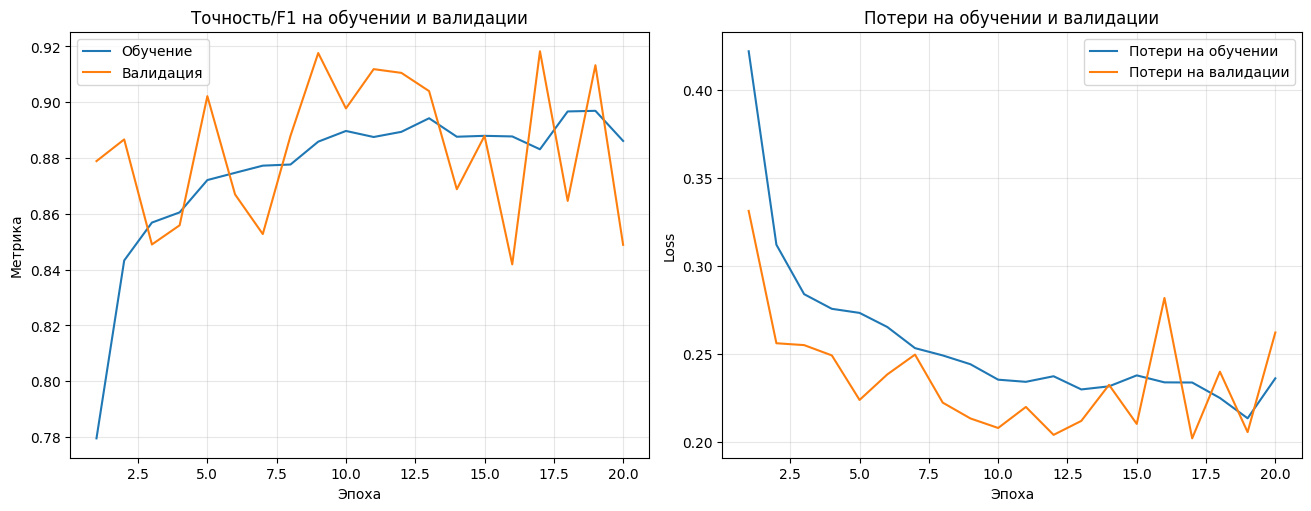

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

history_df = pd.DataFrame(report["history"])

# В старых прогонах у нас есть train_f1/val_f1.
# В новых можно будет добавить train_accuracy/val_accuracy, но пока F1 тоже хорошо показывает динамику.
train_metric_col = "train_accuracy" if "train_accuracy" in history_df.columns else "train_f1"
val_metric_col = "val_accuracy" if "val_accuracy" in history_df.columns else "val_f1"

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].plot(history_df["epoch"], history_df[train_metric_col], label="Обучение")
axes[0].plot(history_df["epoch"], history_df[val_metric_col], label="Валидация")
axes[0].set_title("Точность/F1 на обучении и валидации")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Метрика")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_loss"], label="Потери на обучении")
axes[1].plot(history_df["epoch"], history_df["val_loss"], label="Потери на валидации")
axes[1].set_title("Потери на обучении и валидации")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plot_path = METHOD_DIR / "reports" / "envelope_1d_training_curves.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path, dpi=160)

plot_path


Ячейка 2: сравнение 1D CNN и порогового детектора

In [6]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

THRESHOLD_MAD = 8.0
MIN_PEAK_DISTANCE_S = 0.01

LABEL_TO_INDEX = {"no_burst": 0, "burst": 1}
INDEX_TO_LABEL = {0: "no_burst", 1: "burst"}

def robust_threshold(series_db, threshold_mad):
    median = float(np.median(series_db))
    mad = float(np.median(np.abs(series_db - median)))
    robust_sigma = 1.4826 * mad
    if robust_sigma == 0.0:
        robust_sigma = float(np.std(series_db))
    return median + threshold_mad * robust_sigma

def pick_peaks(series_db, threshold, min_distance_bins):
    if series_db.size < 3:
        return np.array([], dtype=int)

    candidates = np.flatnonzero(
        (series_db[1:-1] >= series_db[:-2]) &
        (series_db[1:-1] > series_db[2:]) &
        (series_db[1:-1] >= threshold)
    ) + 1

    if candidates.size == 0:
        return candidates

    order = candidates[np.argsort(series_db[candidates])[::-1]]
    selected = []
    for idx in order:
        if all(abs(idx - prev) >= min_distance_bins for prev in selected):
            selected.append(int(idx))

    return np.array(sorted(selected), dtype=int)

def threshold_predict_npz(npz_path):
    data = np.load(npz_path)
    envelope_db = data["envelope_db"].astype(np.float32)

    if "time_axis" in data:
        time_axis = data["time_axis"].astype(np.float32)
        if len(time_axis) > 1:
            time_step = float(np.median(np.diff(time_axis)))
        else:
            time_step = 0.002
    else:
        time_step = 0.002

    min_distance_bins = max(1, int(round(MIN_PEAK_DISTANCE_S / time_step)))
    threshold = robust_threshold(envelope_db, THRESHOLD_MAD)
    peaks = pick_peaks(envelope_db, threshold, min_distance_bins)

    return "burst" if len(peaks) > 0 else "no_burst"

def metric_row(y_true_labels, y_pred_labels):
    y_true = np.array([LABEL_TO_INDEX[x] for x in y_true_labels])
    y_pred = np.array([LABEL_TO_INDEX[x] for x in y_pred_labels])

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_burst": precision_score(y_true, y_pred, zero_division=0),
        "recall_burst": recall_score(y_true, y_pred, zero_division=0),
        "f1_burst": f1_score(y_true, y_pred, zero_division=0),
    }

# 1D CNN уже вернул predictions из test split
cnn_predictions = predictions.copy()

threshold_rows = []
for _, row in cnn_predictions.iterrows():
    npz_path = PROJECT_ROOT / "dataset" / str(row["npz_path"]).replace("\\", "/")
    threshold_rows.append({
        "sample_id": row["sample_id"],
        "label": row["label"],
        "predicted": threshold_predict_npz(npz_path),
    })

threshold_predictions = pd.DataFrame(threshold_rows)

cnn_metrics = metric_row(cnn_predictions["label"], cnn_predictions["predicted"])
threshold_metrics = metric_row(threshold_predictions["label"], threshold_predictions["predicted"])

comparison = pd.DataFrame(
    [cnn_metrics, threshold_metrics],
    index=["1D CNN", f"Threshold detector MAD={THRESHOLD_MAD}"]
)

display(comparison)

print("1D CNN confusion matrix:")
print(confusion_matrix(
    [LABEL_TO_INDEX[x] for x in cnn_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in cnn_predictions["predicted"]],
))
print(classification_report(
    [LABEL_TO_INDEX[x] for x in cnn_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in cnn_predictions["predicted"]],
    target_names=["no_burst", "burst"],
    zero_division=0,
))

print("Threshold detector confusion matrix:")
print(confusion_matrix(
    [LABEL_TO_INDEX[x] for x in threshold_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in threshold_predictions["predicted"]],
))
print(classification_report(
    [LABEL_TO_INDEX[x] for x in threshold_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in threshold_predictions["predicted"]],
    target_names=["no_burst", "burst"],
    zero_division=0,
))


,accuracy,precision_burst,recall_burst,f1_burst
1D CNN,0.851852,0.806452,0.925926,0.862069
Threshold detector MAD=8.0,0.648148,0.588889,0.981481,0.736111


1D CNN confusion matrix:
[[42 12]
 [ 4 50]]
              precision    recall  f1-score   support

    no_burst       0.91      0.78      0.84        54
       burst       0.81      0.93      0.86        54

    accuracy                           0.85       108
   macro avg       0.86      0.85      0.85       108
weighted avg       0.86      0.85      0.85       108

Threshold detector confusion matrix:
[[17 37]
 [ 1 53]]
              precision    recall  f1-score   support

    no_burst       0.94      0.31      0.47        54
       burst       0.59      0.98      0.74        54

    accuracy                           0.65       108
   macro avg       0.77      0.65      0.60       108
weighted avg       0.77      0.65      0.60       108



Ячейка 3: гистограмма/столбчатая визуализация

WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/envelope_1d_vs_threshold_metrics.png')

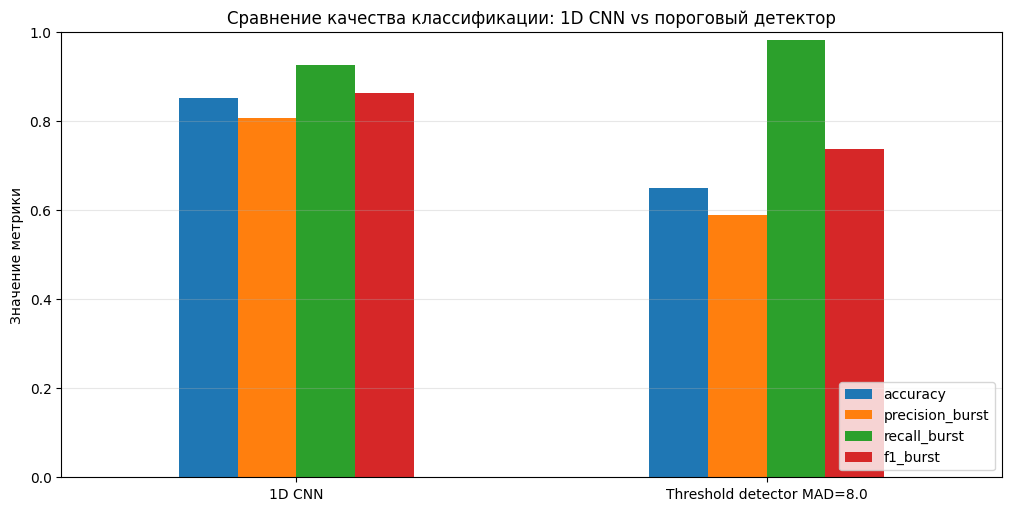

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

comparison.plot(kind="bar", ax=ax)

ax.set_title("Сравнение качества классификации: 1D CNN vs пороговый детектор")
ax.set_ylabel("Значение метрики")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=0)

plot_path = METHOD_DIR / "reports" / "envelope_1d_vs_threshold_metrics.png"
fig.savefig(plot_path, dpi=160)

plot_path


## Manual sample check

Set `SAMPLE` to a `sample_id`, `.npz` path, or `.png` path. The model uses the corresponding `.npz`; PNG is shown only for visual inspection.

In [ ]:
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

metadata = pd.read_csv(PROJECT_ROOT / "dataset" / "metadata.csv")
metadata = metadata[metadata["label"].isin(LABEL_TO_INDEX)].copy()

def row_for_sample(sample: str):
    sample = str(sample).strip().strip('"')
    sample_path = Path(sample.replace("\\", "/"))
    sample_id = sample_path.stem if sample_path.suffix else sample
    rows = metadata[metadata["sample_id"] == sample_id]
    if rows.empty:
        rows = metadata[metadata["npz_path"].astype(str).str.replace("\\", "/", regex=False).str.endswith(sample_path.name)]
    if rows.empty:
        rows = metadata[metadata["png_path"].astype(str).str.replace("\\", "/", regex=False).str.endswith(sample_path.name)]
    if rows.empty:
        raise ValueError(f"Sample not found in metadata: {sample}")
    return rows.iloc[0]

def predict_sample(sample: str, show_image: bool = True):
    row = row_for_sample(sample)
    npz_path = PROJECT_ROOT / "dataset" / Path(str(row["npz_path"]).replace("\\", "/"))
    png_path = PROJECT_ROOT / "dataset" / Path(str(row["png_path"]).replace("\\", "/"))
    data = np.load(npz_path)
    x = data["envelope_db"].astype(np.float32)
    x = (x - x.mean()) / (x.std() + 1e-6)
    x = torch.from_numpy(x[None, None, :])
    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(x), dim=1).cpu().numpy()[0]
    predicted = INDEX_TO_LABEL[int(prob.argmax())]
    print(f"sample_id     : {row['sample_id']}")
    print(f"label         : {row['label']}")
    print(f"predicted     : {predicted}")
    print(f"prob_no_burst : {prob[0]:.4f}")
    print(f"prob_burst    : {prob[1]:.4f}")
    if show_image and png_path.exists():
        display(Image(filename=str(png_path)))

SAMPLE = "sample_000078"
predict_sample(SAMPLE)


In [4]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader
from train_envelope_1d_cnn import EnvelopeDataset

EVAL_DATASET_DIR = PROJECT_ROOT / "dataset"

eval_metadata = pd.read_csv(EVAL_DATASET_DIR / "metadata.csv")
eval_metadata = eval_metadata[eval_metadata["label"].isin(LABEL_TO_INDEX)].copy()
eval_metadata["target"] = eval_metadata["label"].map(LABEL_TO_INDEX).astype(int)

# Проверяем на всех размеченных старых данных, не только test split
eval_loader = DataLoader(
    EnvelopeDataset(eval_metadata, EVAL_DATASET_DIR),
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

model.eval()
all_y = []
all_pred = []
all_prob = []

with torch.no_grad():
    for x, y in eval_loader:
        logits = model(x.to(device))
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        all_y.append(y.numpy())
        all_pred.append(prob.argmax(axis=1))
        all_prob.append(prob)

eval_y = np.concatenate(all_y)
eval_pred = np.concatenate(all_pred)
eval_prob = np.concatenate(all_prob)

print("EVAL on old dataset")
print(confusion_matrix(eval_y, eval_pred))
print(classification_report(
    eval_y,
    eval_pred,
    target_names=["no_burst", "burst"],
    zero_division=0,
))

old_eval_predictions = eval_metadata[[
    "sample_id",
    "source_file",
    "segment_start",
    "segment_end",
    "label",
    "png_path",
    "npz_path",
]].copy()

old_eval_predictions["predicted"] = [INDEX_TO_LABEL[int(value)] for value in eval_pred]
old_eval_predictions["prob_no_burst"] = eval_prob[:, 0]
old_eval_predictions["prob_burst"] = eval_prob[:, 1]
old_eval_predictions["correct"] = old_eval_predictions["label"] == old_eval_predictions["predicted"]

reports_dir = METHOD_DIR / "reports"
reports_dir.mkdir(exist_ok=True)

predictions_path = reports_dir / "envelope_1d_dataset_v2_eval_old_dataset_predictions.csv"
old_eval_predictions.to_csv(predictions_path, index=False)

metrics = {
    "eval_dataset": str(EVAL_DATASET_DIR),
    "samples": int(len(eval_y)),
    "accuracy": float(accuracy_score(eval_y, eval_pred)),
    "precision_burst": float(precision_score(eval_y, eval_pred, zero_division=0)),
    "recall_burst": float(recall_score(eval_y, eval_pred, zero_division=0)),
    "f1_burst": float(f1_score(eval_y, eval_pred, zero_division=0)),
    "confusion_matrix": confusion_matrix(eval_y, eval_pred).tolist(),
}

metrics_path = reports_dir / "envelope_1d_dataset_v2_eval_old_dataset_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

display(pd.DataFrame([metrics]))

print(f"predictions: {predictions_path}")
print(f"metrics: {metrics_path}")


EVAL on old dataset
[[312  43]
 [ 57 298]]
              precision    recall  f1-score   support

    no_burst       0.85      0.88      0.86       355
       burst       0.87      0.84      0.86       355

    accuracy                           0.86       710
   macro avg       0.86      0.86      0.86       710
weighted avg       0.86      0.86      0.86       710



,eval_dataset,samples,accuracy,precision_burst,recall_burst,f1_burst,confusion_matrix
0,C:\code\vlf\Broadband_data\dataset,710,0.859155,0.8739,0.839437,0.856322,"[[312, 43], [57, 298]]"


predictions: c:\code\vlf\Broadband_data\methods\1d_cnn_envelope\reports\envelope_1d_dataset_v2_eval_old_dataset_predictions.csv
metrics: c:\code\vlf\Broadband_data\methods\1d_cnn_envelope\reports\envelope_1d_dataset_v2_eval_old_dataset_metrics.json


Сравнение с пороговым детектором

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

THRESHOLD_MAD = 9.0
MIN_PEAK_DISTANCE_S = 0.01

def robust_threshold(series_db, threshold_mad):
    median = float(np.median(series_db))
    mad = float(np.median(np.abs(series_db - median)))
    robust_sigma = 1.4826 * mad
    if robust_sigma == 0.0:
        robust_sigma = float(np.std(series_db))
    return median + threshold_mad * robust_sigma

def pick_peaks(series_db, threshold, min_distance_bins):
    if series_db.size < 3:
        return np.array([], dtype=int)

    candidates = np.flatnonzero(
        (series_db[1:-1] >= series_db[:-2]) &
        (series_db[1:-1] > series_db[2:]) &
        (series_db[1:-1] >= threshold)
    ) + 1

    if candidates.size == 0:
        return candidates

    order = candidates[np.argsort(series_db[candidates])[::-1]]
    selected = []
    for idx in order:
        if all(abs(idx - prev) >= min_distance_bins for prev in selected):
            selected.append(int(idx))

    return np.array(sorted(selected), dtype=int)

def threshold_predict_npz(npz_path, threshold_mad=THRESHOLD_MAD):
    data = np.load(npz_path)
    envelope_db = data["envelope_db"].astype(np.float32)

    time_axis = data["time_axis"].astype(np.float32)
    time_step = float(np.median(np.diff(time_axis))) if len(time_axis) > 1 else 0.002
    min_distance_bins = max(1, int(round(MIN_PEAK_DISTANCE_S / time_step)))

    threshold = robust_threshold(envelope_db, threshold_mad)
    peaks = pick_peaks(envelope_db, threshold=threshold, min_distance_bins=min_distance_bins)

    return "burst" if len(peaks) > 0 else "no_burst"

def metric_row(y_true_labels, y_pred_labels):
    y_true = np.array([LABEL_TO_INDEX[x] for x in y_true_labels])
    y_pred = np.array([LABEL_TO_INDEX[x] for x in y_pred_labels])

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_burst": precision_score(y_true, y_pred, zero_division=0),
        "recall_burst": recall_score(y_true, y_pred, zero_division=0),
        "f1_burst": f1_score(y_true, y_pred, zero_division=0),
    }

# Берём именно test split dataset_v2
test_v2 = pd.read_csv(DATASET_DIR / "metadata.csv")
test_v2 = test_v2[(test_v2["split"] == "test") & (test_v2["label"].isin(LABEL_TO_INDEX))].copy()

threshold_rows = []

for _, row in test_v2.iterrows():
    npz_path = DATASET_DIR / str(row["npz_path"]).replace("\\", "/")
    threshold_rows.append({
        "sample_id": row["sample_id"],
        "label": row["label"],
        "predicted": threshold_predict_npz(npz_path),
        "npz_path": row["npz_path"],
        "png_path": row["png_path"],
    })

threshold_test_predictions = pd.DataFrame(threshold_rows)

# predictions — это предсказания 1D CNN на test split dataset_v2 из ячейки обучения
cnn_test_predictions = predictions.copy()

comparison_v2_test = pd.DataFrame(
    [
        metric_row(cnn_test_predictions["label"], cnn_test_predictions["predicted"]),
        metric_row(threshold_test_predictions["label"], threshold_test_predictions["predicted"]),
    ],
    index=["1D CNN dataset_v2", f"Threshold detector MAD={THRESHOLD_MAD}"]
)

display(comparison_v2_test)

print("1D CNN confusion matrix:")
print(confusion_matrix(
    [LABEL_TO_INDEX[x] for x in cnn_test_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in cnn_test_predictions["predicted"]],
))
print(classification_report(
    [LABEL_TO_INDEX[x] for x in cnn_test_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in cnn_test_predictions["predicted"]],
    target_names=["no_burst", "burst"],
    zero_division=0,
))

print("Threshold detector confusion matrix:")
print(confusion_matrix(
    [LABEL_TO_INDEX[x] for x in threshold_test_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in threshold_test_predictions["predicted"]],
))
print(classification_report(
    [LABEL_TO_INDEX[x] for x in threshold_test_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in threshold_test_predictions["predicted"]],
    target_names=["no_burst", "burst"],
    zero_division=0,
))

reports_dir = METHOD_DIR / "reports"
reports_dir.mkdir(exist_ok=True)

threshold_predictions_path = reports_dir / "threshold_detector_mad10_dataset_v2_test_predictions.csv"
threshold_test_predictions.to_csv(threshold_predictions_path, index=False)

comparison_path = reports_dir / "cnn_vs_threshold_dataset_v2_test_metrics.csv"
comparison_v2_test.to_csv(comparison_path)

print(f"threshold predictions: {threshold_predictions_path}")
print(f"comparison metrics: {comparison_path}")


,accuracy,precision_burst,recall_burst,f1_burst
1D CNN dataset_v2,0.898778,0.888889,0.881890,0.885375
Threshold detector MAD=9.0,0.923211,1.000000,0.826772,0.905172


1D CNN confusion matrix:
[[291  28]
 [ 30 224]]
              precision    recall  f1-score   support

    no_burst       0.91      0.91      0.91       319
       burst       0.89      0.88      0.89       254

    accuracy                           0.90       573
   macro avg       0.90      0.90      0.90       573
weighted avg       0.90      0.90      0.90       573

Threshold detector confusion matrix:
[[319   0]
 [ 44 210]]
              precision    recall  f1-score   support

    no_burst       0.88      1.00      0.94       319
       burst       1.00      0.83      0.91       254

    accuracy                           0.92       573
   macro avg       0.94      0.91      0.92       573
weighted avg       0.93      0.92      0.92       573

threshold predictions: c:\code\vlf\Broadband_data\methods\1d_cnn_envelope\reports\threshold_detector_mad10_dataset_v2_test_predictions.csv
comparison metrics: c:\code\vlf\Broadband_data\methods\1d_cnn_envelope\reports\cnn_vs_threshold_dat

WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/cnn_vs_threshold_dataset_v2_test_metrics.png')

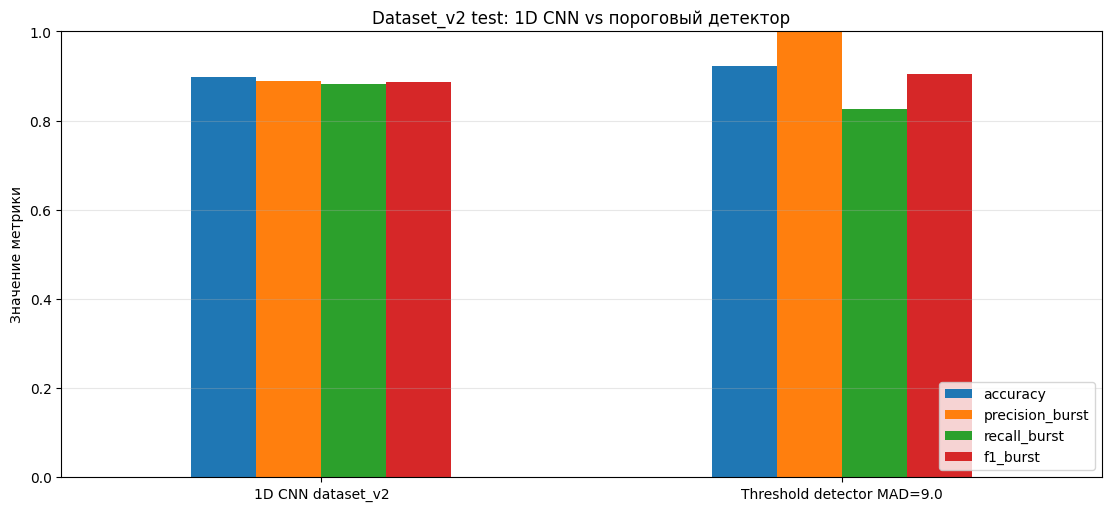

In [10]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

comparison_v2_test.plot(kind="bar", ax=ax)

ax.set_title("Dataset_v2 test: 1D CNN vs пороговый детектор")
ax.set_ylabel("Значение метрики")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=0)

plot_path = METHOD_DIR / "reports" / "cnn_vs_threshold_dataset_v2_test_metrics.png"
fig.savefig(plot_path, dpi=160)

plot_path


Сравнение на старом датасете

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

OLD_DATASET_DIR = PROJECT_ROOT / "dataset"
THRESHOLD_MAD = 8.0
MIN_PEAK_DISTANCE_S = 0.01

def robust_threshold(series_db, threshold_mad):
    median = float(np.median(series_db))
    mad = float(np.median(np.abs(series_db - median)))
    robust_sigma = 1.4826 * mad
    if robust_sigma == 0.0:
        robust_sigma = float(np.std(series_db))
    return median + threshold_mad * robust_sigma

def pick_peaks(series_db, threshold, min_distance_bins):
    if series_db.size < 3:
        return np.array([], dtype=int)

    candidates = np.flatnonzero(
        (series_db[1:-1] >= series_db[:-2]) &
        (series_db[1:-1] > series_db[2:]) &
        (series_db[1:-1] >= threshold)
    ) + 1

    if candidates.size == 0:
        return candidates

    order = candidates[np.argsort(series_db[candidates])[::-1]]
    selected = []
    for idx in order:
        if all(abs(idx - prev) >= min_distance_bins for prev in selected):
            selected.append(int(idx))

    return np.array(sorted(selected), dtype=int)

def threshold_predict_npz(npz_path, threshold_mad=THRESHOLD_MAD):
    data = np.load(npz_path)
    envelope_db = data["envelope_db"].astype(np.float32)

    time_axis = data["time_axis"].astype(np.float32)
    time_step = float(np.median(np.diff(time_axis))) if len(time_axis) > 1 else 0.002
    min_distance_bins = max(1, int(round(MIN_PEAK_DISTANCE_S / time_step)))

    threshold = robust_threshold(envelope_db, threshold_mad)
    peaks = pick_peaks(envelope_db, threshold=threshold, min_distance_bins=min_distance_bins)

    return "burst" if len(peaks) > 0 else "no_burst"

def metric_row(y_true_labels, y_pred_labels):
    y_true = np.array([LABEL_TO_INDEX[x] for x in y_true_labels])
    y_pred = np.array([LABEL_TO_INDEX[x] for x in y_pred_labels])

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_burst": precision_score(y_true, y_pred, zero_division=0),
        "recall_burst": recall_score(y_true, y_pred, zero_division=0),
        "f1_burst": f1_score(y_true, y_pred, zero_division=0),
    }

# Если old_eval_predictions уже есть после проверки CNN на старом dataset, используем её.
# Если нет, читаем predictions-файл.
try:
    cnn_old_predictions = old_eval_predictions.copy()
except NameError:
    cnn_old_predictions = pd.read_csv(
        METHOD_DIR / "reports" / "envelope_1d_dataset_v2_eval_old_dataset_predictions.csv"
    )

threshold_rows = []

for _, row in cnn_old_predictions.iterrows():
    npz_path = OLD_DATASET_DIR / str(row["npz_path"]).replace("\\", "/")
    threshold_rows.append({
        "sample_id": row["sample_id"],
        "label": row["label"],
        "predicted": threshold_predict_npz(npz_path),
        "npz_path": row["npz_path"],
        "png_path": row["png_path"],
    })

threshold_old_predictions = pd.DataFrame(threshold_rows)

comparison_old_dataset = pd.DataFrame(
    [
        metric_row(cnn_old_predictions["label"], cnn_old_predictions["predicted"]),
        metric_row(threshold_old_predictions["label"], threshold_old_predictions["predicted"]),
    ],
    index=["1D CNN dataset_v2 -> old dataset", f"Threshold detector MAD={THRESHOLD_MAD}"]
)

display(comparison_old_dataset)

print("1D CNN on old dataset confusion matrix:")
print(confusion_matrix(
    [LABEL_TO_INDEX[x] for x in cnn_old_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in cnn_old_predictions["predicted"]],
))
print(classification_report(
    [LABEL_TO_INDEX[x] for x in cnn_old_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in cnn_old_predictions["predicted"]],
    target_names=["no_burst", "burst"],
    zero_division=0,
))

print("Threshold detector on old dataset confusion matrix:")
print(confusion_matrix(
    [LABEL_TO_INDEX[x] for x in threshold_old_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in threshold_old_predictions["predicted"]],
))
print(classification_report(
    [LABEL_TO_INDEX[x] for x in threshold_old_predictions["label"]],
    [LABEL_TO_INDEX[x] for x in threshold_old_predictions["predicted"]],
    target_names=["no_burst", "burst"],
    zero_division=0,
))

reports_dir = METHOD_DIR / "reports"
reports_dir.mkdir(exist_ok=True)

threshold_predictions_path = reports_dir / f"threshold_detector_mad{THRESHOLD_MAD:g}_old_dataset_predictions.csv"
threshold_old_predictions.to_csv(threshold_predictions_path, index=False)

comparison_path = reports_dir / f"cnn_vs_threshold_mad{THRESHOLD_MAD:g}_old_dataset_metrics.csv"
comparison_old_dataset.to_csv(comparison_path)

print(f"threshold predictions: {threshold_predictions_path}")
print(f"comparison metrics: {comparison_path}")


,accuracy,precision_burst,recall_burst,f1_burst
1D CNN dataset_v2 -> old dataset,0.859155,0.873900,0.839437,0.856322
Threshold detector MAD=8.0,0.681690,0.612174,0.991549,0.756989


1D CNN on old dataset confusion matrix:
[[312  43]
 [ 57 298]]
              precision    recall  f1-score   support

    no_burst       0.85      0.88      0.86       355
       burst       0.87      0.84      0.86       355

    accuracy                           0.86       710
   macro avg       0.86      0.86      0.86       710
weighted avg       0.86      0.86      0.86       710

Threshold detector on old dataset confusion matrix:
[[132 223]
 [  3 352]]
              precision    recall  f1-score   support

    no_burst       0.98      0.37      0.54       355
       burst       0.61      0.99      0.76       355

    accuracy                           0.68       710
   macro avg       0.79      0.68      0.65       710
weighted avg       0.79      0.68      0.65       710

threshold predictions: c:\code\vlf\Broadband_data\methods\1d_cnn_envelope\reports\threshold_detector_mad8_old_dataset_predictions.csv
comparison metrics: c:\code\vlf\Broadband_data\methods\1d_cnn_envelope\rep

WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/cnn_vs_threshold_mad8_old_dataset_metrics.png')

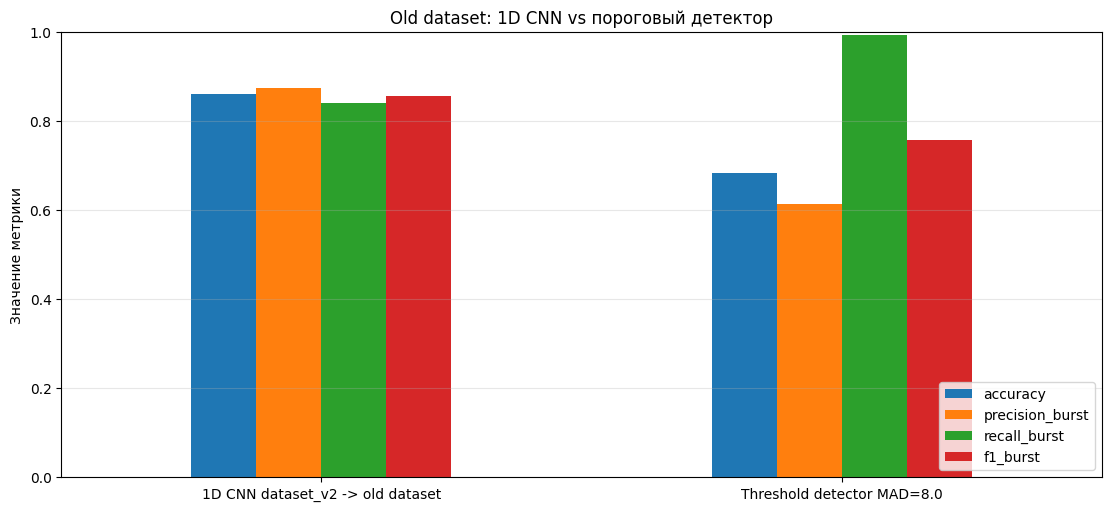

In [12]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

comparison_old_dataset.plot(kind="bar", ax=ax)

ax.set_title("Old dataset: 1D CNN vs пороговый детектор")
ax.set_ylabel("Значение метрики")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=0)

plot_path = METHOD_DIR / "reports" / f"cnn_vs_threshold_mad{THRESHOLD_MAD:g}_old_dataset_metrics.png"
fig.savefig(plot_path, dpi=160)

plot_path


,1D CNN,Пороговый детектор
Верно найденные\nсобытия,298,352
Пропущенные\nсобытия,57,3
Ложные\nсрабатывания,43,223
Верно отклонённые\nфрагменты,312,132


WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/classification_distribution_old_dataset_ru.png')

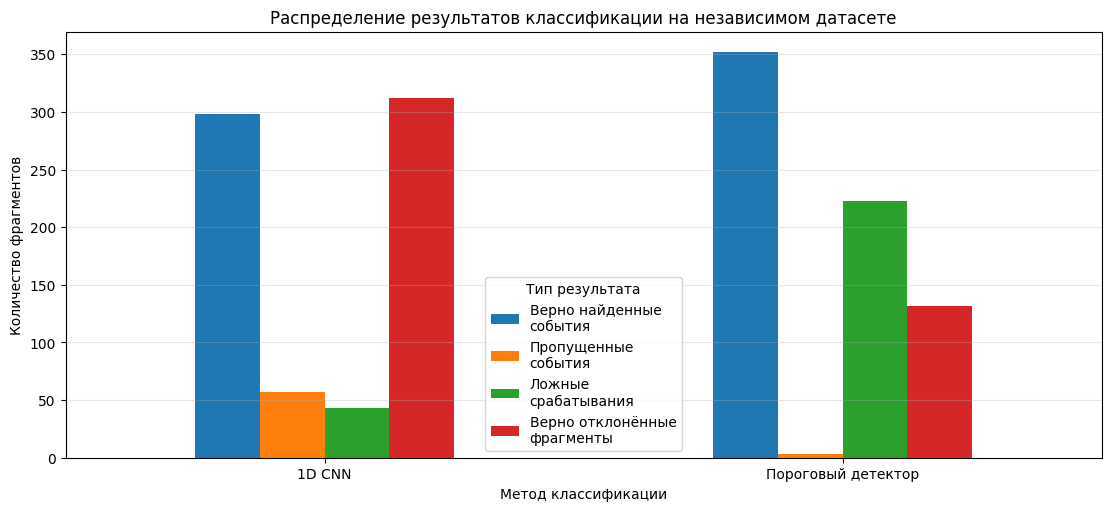

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

cnn_path = METHOD_DIR / "reports" / "envelope_1d_dataset_v2_eval_old_dataset_predictions.csv"
threshold_path = METHOD_DIR / "reports" / "threshold_detector_mad8_old_dataset_predictions.csv"

cnn = pd.read_csv(cnn_path)
thr = pd.read_csv(threshold_path)

def error_counts(df):
    label = df["label"]
    pred = df["predicted"]

    return {
        "Верно найденные\nсобытия": ((label == "burst") & (pred == "burst")).sum(),
        "Пропущенные\nсобытия": ((label == "burst") & (pred == "no_burst")).sum(),
        "Ложные\nсрабатывания": ((label == "no_burst") & (pred == "burst")).sum(),
        "Верно отклонённые\nфрагменты": ((label == "no_burst") & (pred == "no_burst")).sum(),
    }

counts = pd.DataFrame(
    {
        "1D CNN": error_counts(cnn),
        "Пороговый детектор": error_counts(thr),
    }
)

display(counts)

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

counts.T.plot(kind="bar", ax=ax)

ax.set_title("Распределение результатов классификации на независимом датасете")
ax.set_ylabel("Количество фрагментов")
ax.set_xlabel("Метод классификации")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Тип результата")

plot_path = METHOD_DIR / "reports" / "classification_distribution_old_dataset_ru.png"
fig.savefig(plot_path, dpi=200)

plot_path


WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/classification_errors_old_dataset_ru.png')

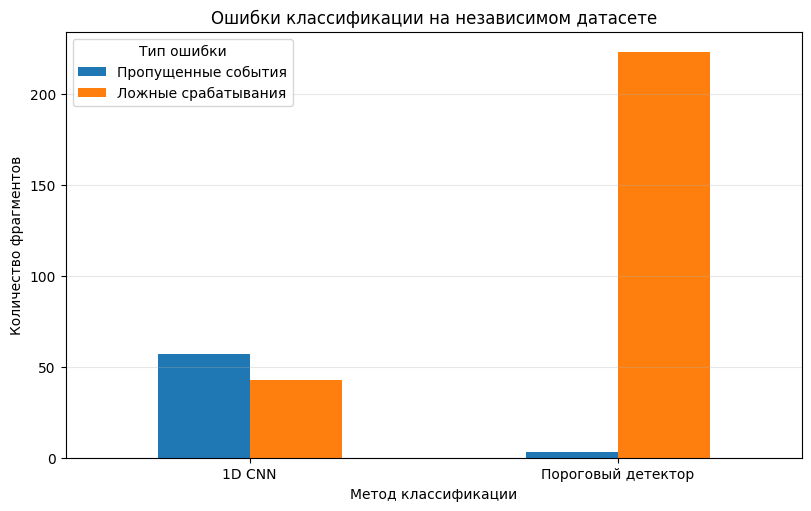

In [14]:
error_counts_only = pd.DataFrame(
    {
        "1D CNN": {
            "Пропущенные события": 57,
            "Ложные срабатывания": 43,
        },
        "Пороговый детектор": {
            "Пропущенные события": 3,
            "Ложные срабатывания": 223,
        },
    }
)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

error_counts_only.T.plot(kind="bar", ax=ax)

ax.set_title("Ошибки классификации на независимом датасете")
ax.set_ylabel("Количество фрагментов")
ax.set_xlabel("Метод классификации")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Тип ошибки")

plot_path = METHOD_DIR / "reports" / "classification_errors_old_dataset_ru.png"
fig.savefig(plot_path, dpi=200)

plot_path


WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/envelope_1d_f1_smoothed.png')

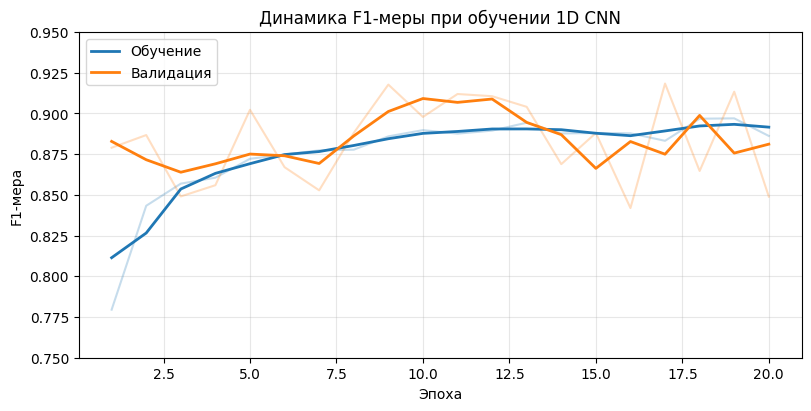

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

history_df = pd.DataFrame(report["history"])

window = 3

history_df["train_f1_smooth"] = history_df["train_f1"].rolling(window=window, center=True, min_periods=1).mean()
history_df["val_f1_smooth"] = history_df["val_f1"].rolling(window=window, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

ax.plot(history_df["epoch"], history_df["train_f1"], alpha=0.25, color="tab:blue")
ax.plot(history_df["epoch"], history_df["val_f1"], alpha=0.25, color="tab:orange")

ax.plot(history_df["epoch"], history_df["train_f1_smooth"], label="Обучение", color="tab:blue", linewidth=2)
ax.plot(history_df["epoch"], history_df["val_f1_smooth"], label="Валидация", color="tab:orange", linewidth=2)

ax.set_title("Динамика F1-меры при обучении 1D CNN")
ax.set_xlabel("Эпоха")
ax.set_ylabel("F1-мера")
ax.set_ylim(0.75, 0.95)
ax.grid(True, alpha=0.3)
ax.legend()

plot_path = METHOD_DIR / "reports" / "envelope_1d_f1_smoothed.png"
fig.savefig(plot_path, dpi=200)

plot_path


WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/envelope_1d_loss.png')

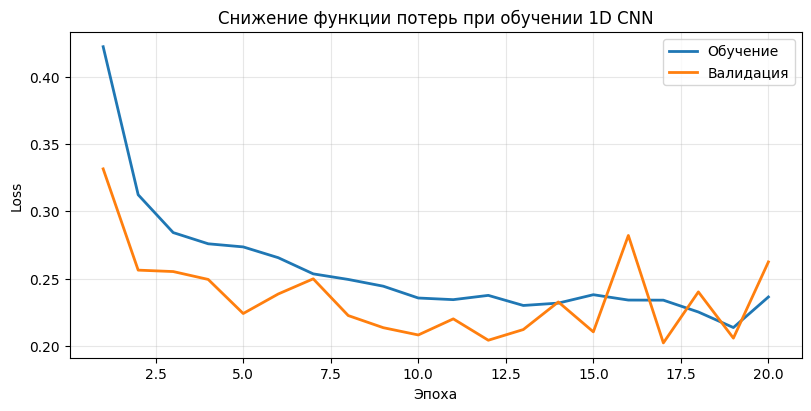

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

ax.plot(history_df["epoch"], history_df["train_loss"], label="Обучение", linewidth=2)
ax.plot(history_df["epoch"], history_df["val_loss"], label="Валидация", linewidth=2)

ax.set_title("Снижение функции потерь при обучении 1D CNN")
ax.set_xlabel("Эпоха")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()

plot_path = METHOD_DIR / "reports" / "envelope_1d_loss.png"
fig.savefig(plot_path, dpi=200)

plot_path


WindowsPath('c:/code/vlf/Broadband_data/methods/1d_cnn_envelope/reports/envelope_1d_test_metrics_bar.png')

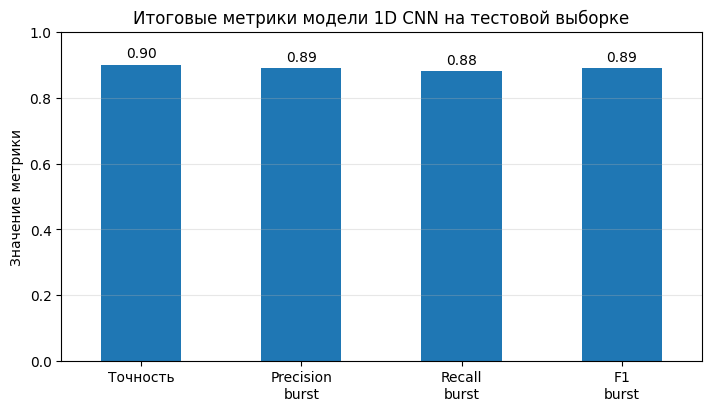

In [9]:
metrics = pd.DataFrame(
    {
        "Точность": [0.90],
        "Precision\nburst": [0.89],
        "Recall\nburst": [0.88],
        "F1\nburst": [0.89],
    },
    index=["1D CNN"]
)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

metrics.T.plot(kind="bar", ax=ax, legend=False, color="tab:blue")

ax.set_title("Итоговые метрики модели 1D CNN на тестовой выборке")
ax.set_ylabel("Значение метрики")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plot_path = METHOD_DIR / "reports" / "envelope_1d_test_metrics_bar.png"
fig.savefig(plot_path, dpi=200)

plot_path
